# 02d — Colab Final Evaluation

No training here -- only needs a weights file path. Re-running individual cells to redo a plot
never risks training progress.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.8 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path

SCRIPTS_DIR = Path("/content/drive/Shareddrives/Computer Vision Final Project/Modeling/YOLO")
sys.path.insert(0, str(SCRIPTS_DIR))

from yolo_common_colab import *
import random

data_yaml_path, data_yaml, unified_classes, train_image_paths, val_image_paths, test_image_paths = load_dataset()
class_colors = get_class_colors(unified_classes)

sweep_csv_path = RUNS_DIR / "hyperparameter_sweep_results.csv"
if sweep_csv_path.exists():
    _best = pd.read_csv(sweep_csv_path).sort_values("mAP50-95", ascending=False).iloc[0]
    print(f"Best config in sweep CSV: {_best['config']} (mAP50-95={_best['mAP50-95']:.4f})")
    print("If you want to evaluate that config instead of the baseline, set BEST_RUN_NAME below accordingly.")
else:
    print("No hyperparameter sweep run -- evaluating the baseline model directly.")

# Baseline (yolov8s, 30 epochs, full dataset) -- final mAP50=0.366, mAP50-95=0.221.
# Change this to f"tune_{_best['config']}" instead if you did run 02c and want to evaluate that.
BEST_RUN_NAME = "baseline_yolov8s"
best_weights = RUNS_DIR / BEST_RUN_NAME / "weights" / "best.pt"
assert best_weights.exists(), f"{best_weights} not found -- check BEST_RUN_NAME."

from ultralytics import YOLO
best_model = YOLO(str(best_weights))
print(f"Loaded {best_weights}")


Extracting /content/drive/Shareddrives/Computer Vision Final Project/Data/tar_datasets/fv40_merged.tar (3017 MB) -> /content/dataset...
34929 entries in the tar
  2000/34929  (22 files/s, ~24.6 min left)
  4000/34929  (44 files/s, ~11.8 min left)
  6000/34929  (64 files/s, ~7.5 min left)
  8000/34929  (82 files/s, ~5.5 min left)
  10000/34929  (102 files/s, ~4.1 min left)
  12000/34929  (120 files/s, ~3.2 min left)
  14000/34929  (139 files/s, ~2.5 min left)
  16000/34929  (158 files/s, ~2.0 min left)
  18000/34929  (165 files/s, ~1.7 min left)
  20000/34929  (183 files/s, ~1.4 min left)
  22000/34929  (201 files/s, ~1.1 min left)
  24000/34929  (219 files/s, ~0.8 min left)
  26000/34929  (237 files/s, ~0.6 min left)
  28000/34929  (254 files/s, ~0.5 min left)
  30000/34929  (272 files/s, ~0.3 min left)
  32000/34929  (290 files/s, ~0.2 min left)
  34000/34929  (307 files/s, ~0.1 min left)
  34929/34929  (316 files/s, ~0.0 min left)
Extraction complete in 1.8 min.
Extracting /content/d

## Metrics on the held-out test set

In [3]:
test_metrics = best_model.val(data=str(data_yaml_path), split="test", imgsz=640, conf=0.25, iou=0.45)

print(f"mAP@50:     {test_metrics.box.map50:.4f}")
print(f"mAP@50:95:  {test_metrics.box.map:.4f}")
print(f"Precision:  {test_metrics.box.mp:.4f}")
print(f"Recall:     {test_metrics.box.mr:.4f}")


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,182,860 parameters, 0 gradients, 28.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 537.8±732.2 MB/s, size: 73.9 KB)
val: Scanning /content/dataset/food_ingredients/test/labels... 1902 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1902/1902 456.0it/s 4.2s
val: New cache created: /content/dataset/food_ingredients/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 119/119 3.9it/s 30.5s
                   all       1902      30832       0.44      0.277      0.247      0.146
                almond          2         56      0.586      0.304      0.264      0.177
                 apple        308       2165       0.49      0.601      0.496      0.402
               apricot          1          4          0          0          0          0
             artichoke          4         52

46 classes have no test-set instances, excluded from this table: ['akabare khursani', 'ash gourd', 'bamboo shoots', 'black beans', 'black lentils', 'broad beans', 'cassava', 'chayote', 'chicken gizzards', 'cinnamon', 'crab meat', 'date', 'farsi ko munta', 'fig', 'fish', 'garden cress', 'garden peas', 'gourd', 'green lentils', 'green peas', 'green soyabean', 'ice', 'jack fruit', 'lapsi', 'long beans', 'masyaura', 'milk', 'noodle', 'okra', 'olive oil', 'palak', 'persimmon', 'pointed gourd', 'prune', 'red lentils', 'sausage', 'seaweed', 'snake gourd', 'soyabean', 'sponge gourd', 'stinging nettle', 'taro root', 'thukpa noodles', 'wallnut', 'wheat', 'yellow lentils']


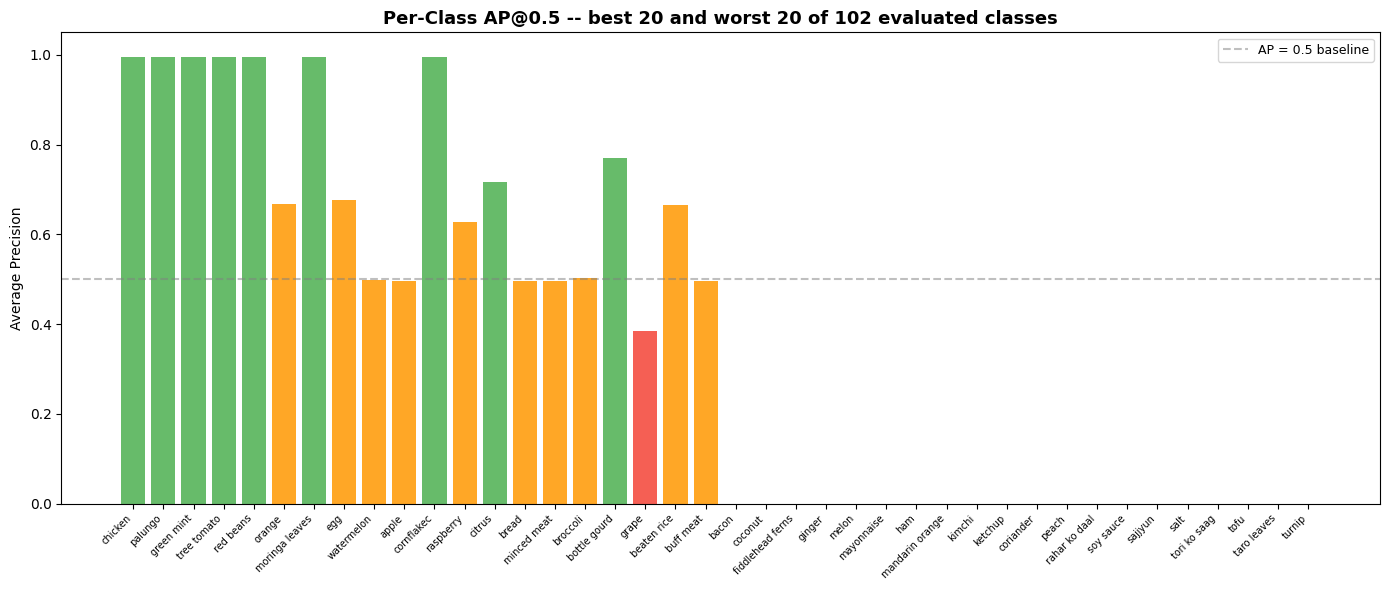

Color key: green = AP >= 0.7, orange = 0.4-0.7, red = < 0.4


,class,AP50,AP50-95
31,chicken,0.995000,0.796000
71,palungo,0.995000,0.796000
51,green mint,0.995000,0.595500
98,tree tomato,0.995000,0.576500
86,red beans,0.995000,0.546500
70,orange,0.668348,0.510871
65,moringa leaves,0.995000,0.497500
43,egg,0.675909,0.418652
100,watermelon,0.498997,0.408392
1,apple,0.496387,0.402085


In [4]:
# ap_class_index holds the actual class ids Ultralytics computed metrics for -- shorter than the
# full 148-class list whenever a class has zero test-set instances (confirmed earlier: 2 of 148
# classes had zero TRAIN instances too, so this isn't a surprise). Align by that index rather than
# assuming every class is present, or the arrays won't line up.
evaluated_class_ids = test_metrics.box.ap_class_index
evaluated_class_names = [unified_classes[i] for i in evaluated_class_ids]

per_class_ap = pd.DataFrame({
    "class": evaluated_class_names,
    "AP50": test_metrics.box.ap50,
    "AP50-95": test_metrics.box.ap,
})
per_class_ap = per_class_ap.sort_values("AP50-95", ascending=False)
per_class_ap.to_csv(RUNS_DIR / "per_class_ap.csv", index=False)

missing_classes = sorted(set(unified_classes) - set(evaluated_class_names))
if missing_classes:
    print(f"{len(missing_classes)} classes have no test-set instances, excluded from this table: {missing_classes}")

top_n = 20
plot_df = pd.concat([per_class_ap.head(top_n), per_class_ap.tail(top_n)])
bar_colors = ["#4CAF50" if ap >= 0.7 else "#FF9800" if ap >= 0.4 else "#F44336" for ap in plot_df["AP50"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df["class"], plot_df["AP50"], color=bar_colors, alpha=0.85)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="AP = 0.5 baseline")
ax.set_title(f"Per-Class AP@0.5 -- best {top_n} and worst {top_n} of {len(evaluated_class_names)} evaluated classes", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Precision")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

print("Color key: green = AP >= 0.7, orange = 0.4-0.7, red = < 0.4")
per_class_ap.head(15)


## Per-object-size AP breakdown

In [5]:
from ultralytics.utils.metrics import box_iou
import torch

def gt_boxes_for_image(label_path, img_w, img_h):
    boxes, classes = [], []
    if not label_path.exists():
        return boxes, classes
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cid, xc, yc, w, h = int(parts[0]), *map(float, parts[1:5])
        x1 = (xc - w / 2) * img_w
        y1 = (yc - h / 2) * img_h
        x2 = (xc + w / 2) * img_w
        y2 = (yc + h / 2) * img_h
        boxes.append([x1, y1, x2, y2])
        classes.append(cid)
    return boxes, classes

def size_bucket(box_w, box_h, img_w, img_h):
    frac = (box_w * box_h) / (img_w * img_h)
    if frac < 0.01:
        return "small"
    elif frac < 0.1:
        return "medium"
    return "large"

size_hits = defaultdict(lambda: {"tp": 0, "total": 0})
IOU_THRESH = 0.5

for i, img_path in enumerate(test_image_paths, start=1):
    label_path = img2label_path(img_path)
    with Image.open(img_path) as im:
        img_w, img_h = im.size

    gt_boxes, gt_classes = gt_boxes_for_image(label_path, img_w, img_h)
    if not gt_boxes:
        continue

    pred = best_model.predict(str(img_path), imgsz=640, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes = pred.boxes.xyxy.cpu() if len(pred.boxes) else torch.empty((0, 4))
    pred_classes = pred.boxes.cls.cpu().tolist() if len(pred.boxes) else []

    gt_tensor = torch.tensor(gt_boxes, dtype=torch.float32)
    ious = box_iou(gt_tensor, pred_boxes) if len(pred_boxes) else torch.zeros((len(gt_boxes), 0))

    for j, (box, cid) in enumerate(zip(gt_boxes, gt_classes)):
        bw, bh = box[2] - box[0], box[3] - box[1]
        bucket = size_bucket(bw, bh, img_w, img_h)
        matched = False
        if ious.shape[1] > 0:
            best_iou, best_j = ious[j].max(0)
            if best_iou >= IOU_THRESH and pred_classes[best_j] == cid:
                matched = True
        size_hits[bucket]["total"] += 1
        size_hits[bucket]["tp"] += int(matched)

    if i % 250 == 0 or i == len(test_image_paths):
        print(f"  {i}/{len(test_image_paths)}")

size_df = pd.DataFrame([
    {"size": k, "recall_at_iou50": v["tp"] / v["total"] if v["total"] else 0, "n_boxes": v["total"]}
    for k, v in size_hits.items()
]).sort_values("size")

size_df.to_csv(RUNS_DIR / "per_size_recall.csv", index=False)
size_df


  250/1902
  500/1902
  750/1902
  1000/1902
  1250/1902
  1500/1902
  1750/1902
  1902/1902


,size,recall_at_iou50,n_boxes
2,large,0.736315,1297
1,medium,0.634506,5431
0,small,0.404871,24104


## Confusion matrix

Extra **background** row/column vs. a classification confusion matrix:
- `predicted=background, true=<ingredient>` → missed object (false negative)
- `predicted=<ingredient>, true=background` → hallucinated object (false positive)
- Off-diagonal between two real classes → found the object, confused its type

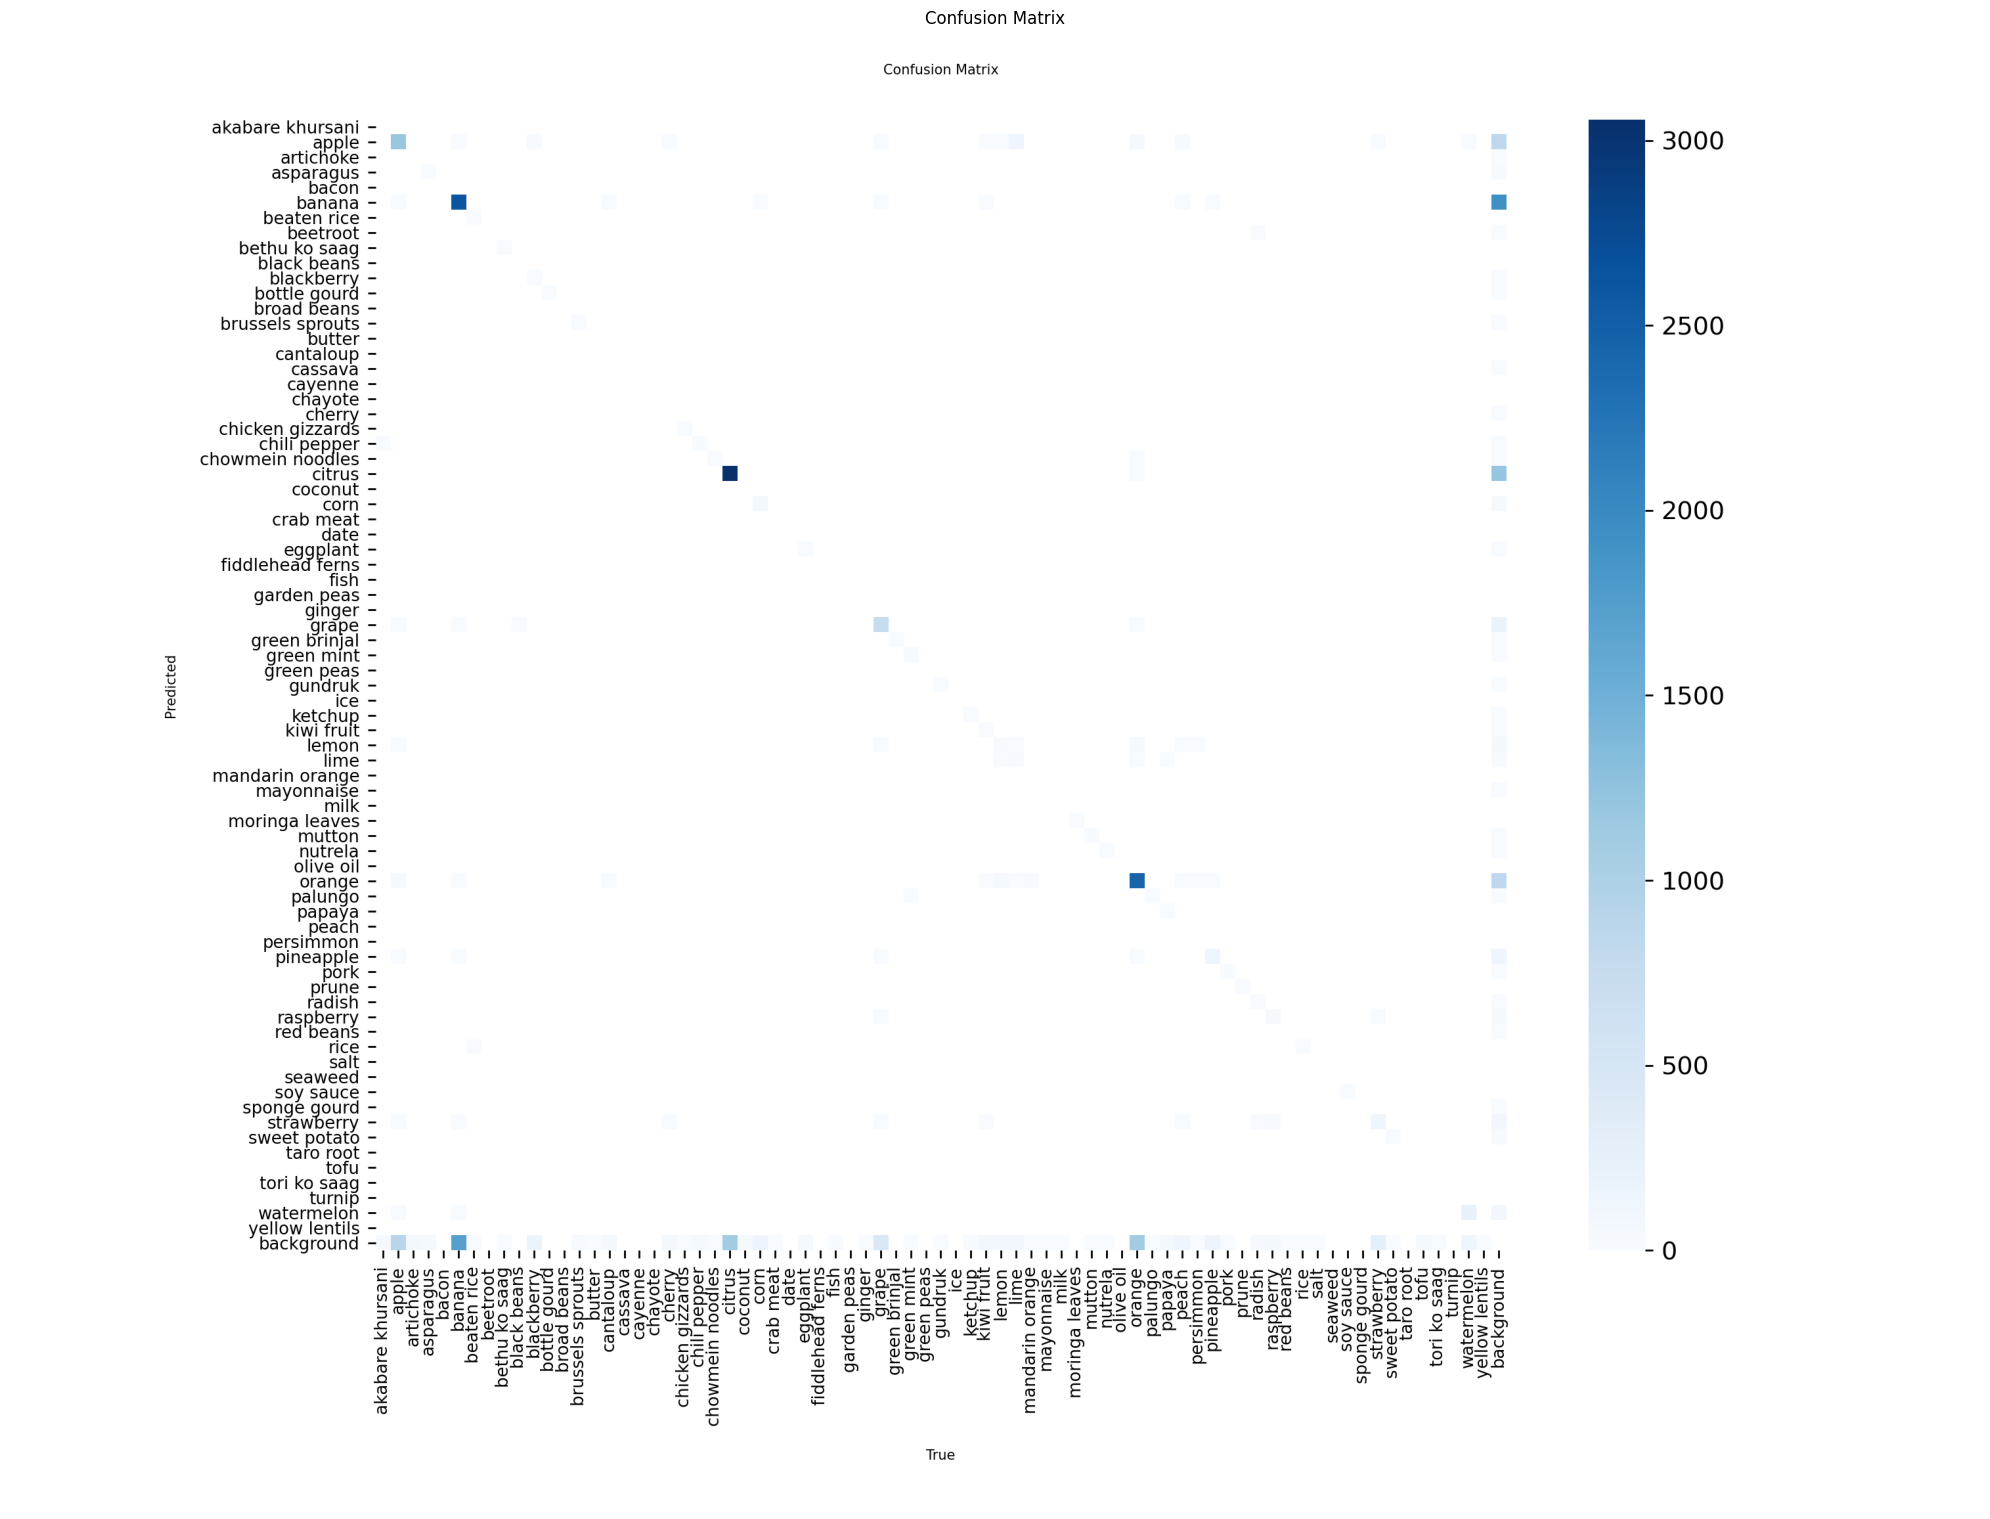

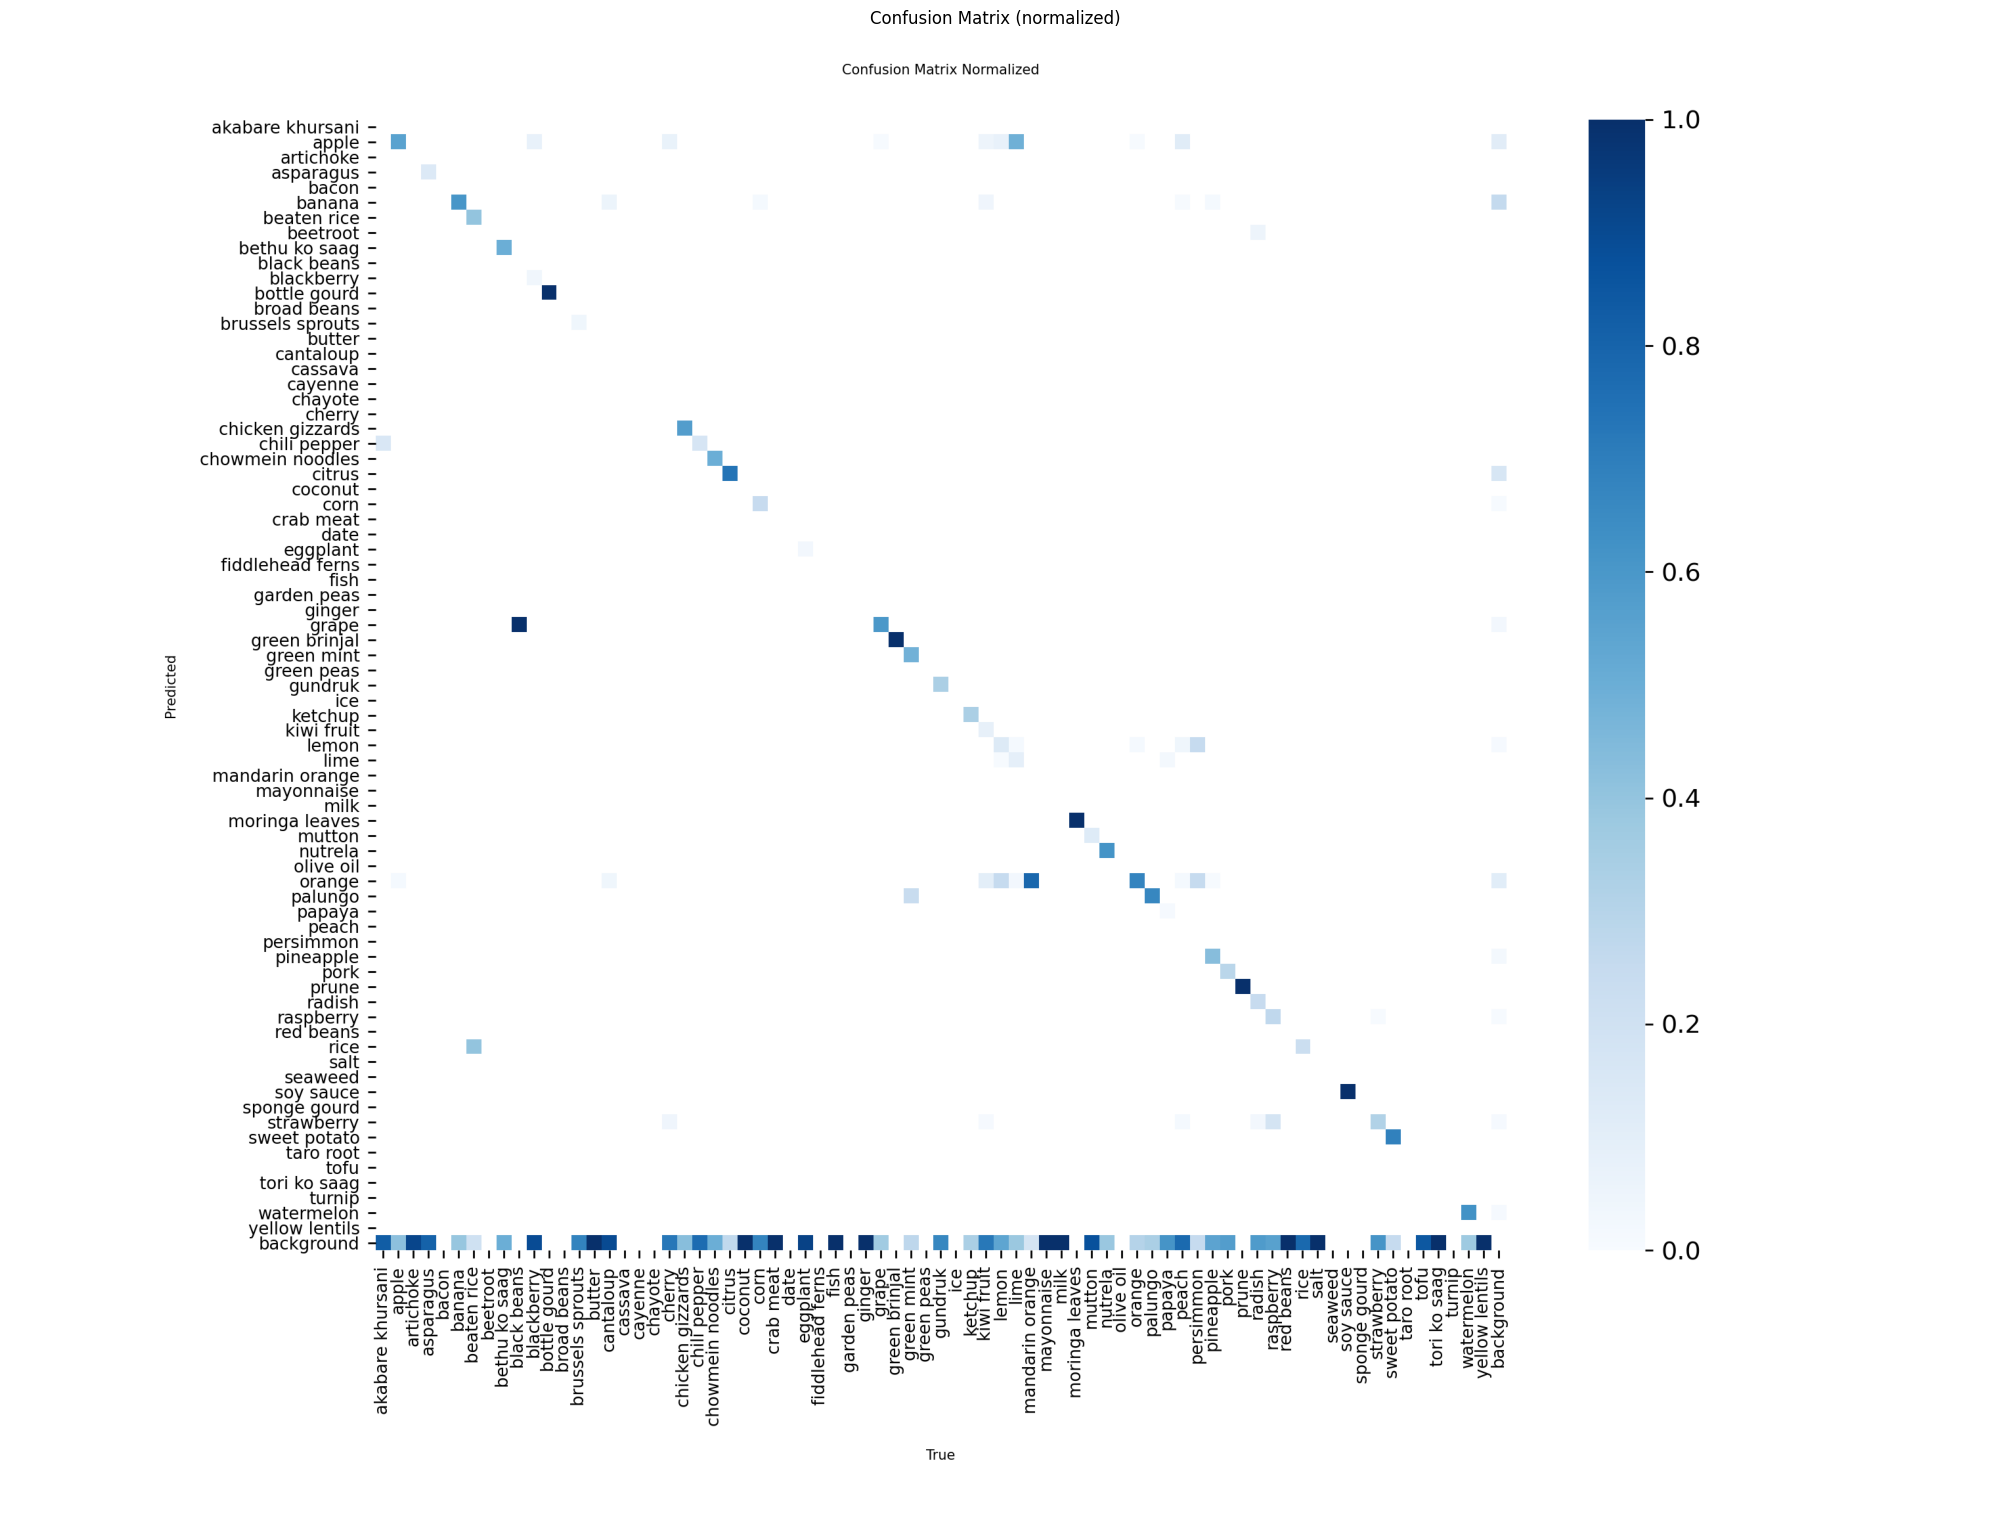

In [6]:
from PIL import Image as PILImage

val_run_dir = sorted((RUNS_DIR).glob(f"{BEST_RUN_NAME}*"))[-1]

for name, label in [("confusion_matrix.png", "Confusion Matrix"),
                     ("confusion_matrix_normalized.png", "Confusion Matrix (normalized)")]:
    cm_path = val_run_dir / name
    if cm_path.exists():
        fig, ax = plt.subplots(figsize=(20, 16))
        ax.imshow(PILImage.open(cm_path))
        ax.set_title(label, fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{name} not found at {cm_path} -- check the val() run folder name.")


## Predictions vs ground truth

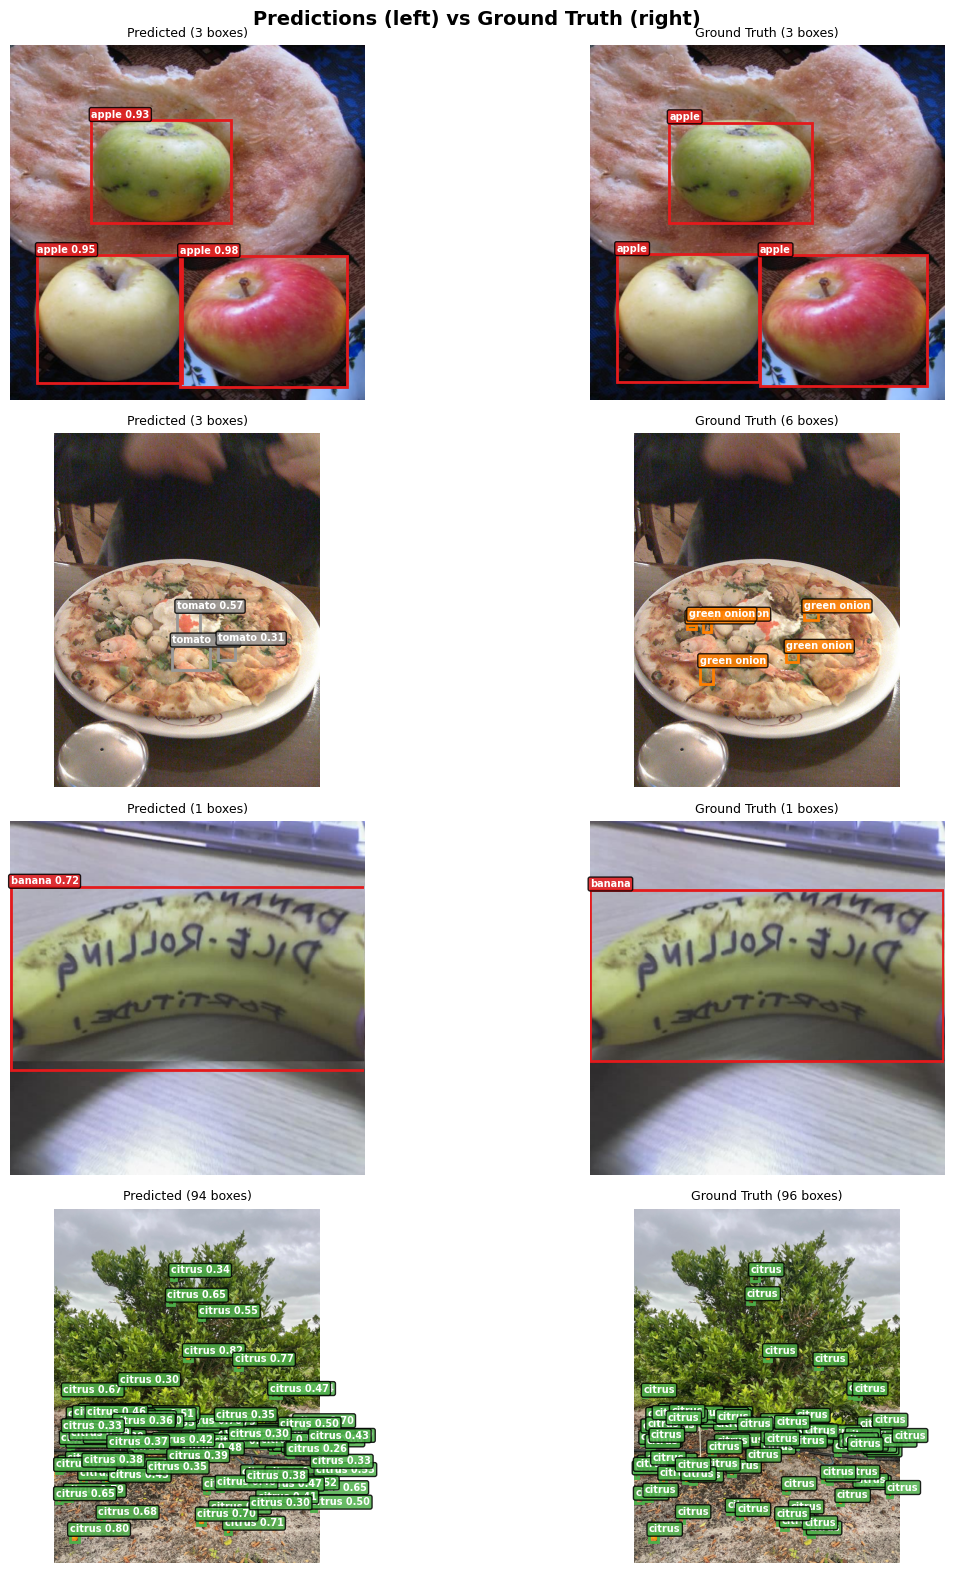

In [7]:
sample_imgs = random.sample(test_image_paths, 4)
results = best_model.predict([str(p) for p in sample_imgs], imgsz=640, conf=0.25, iou=0.45, verbose=False)

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(14, len(sample_imgs) * 4))
fig.suptitle("Predictions (left) vs Ground Truth (right)", fontsize=14, fontweight="bold")

for row, (result, img_path) in enumerate(zip(results, sample_imgs)):
    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size

    axes[row, 0].imshow(img)
    pred_boxes = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        pred_boxes.append((box.cls[0].item(), x1, y1, x2 - x1, y2 - y1, box.conf[0].item()))
    draw_boxes(axes[row, 0], pred_boxes, unified_classes, class_colors, f"Predicted ({len(pred_boxes)} boxes)")

    axes[row, 1].imshow(img)
    label_path = img2label_path(img_path)
    gt_boxes = [(c, x, y, w, h, None) for c, x, y, w, h in parse_yolo_label(label_path, img_w, img_h)]
    draw_boxes(axes[row, 1], gt_boxes, unified_classes, class_colors, f"Ground Truth ({len(gt_boxes)} boxes)")

plt.tight_layout()
plt.show()


### Confidence threshold experiment

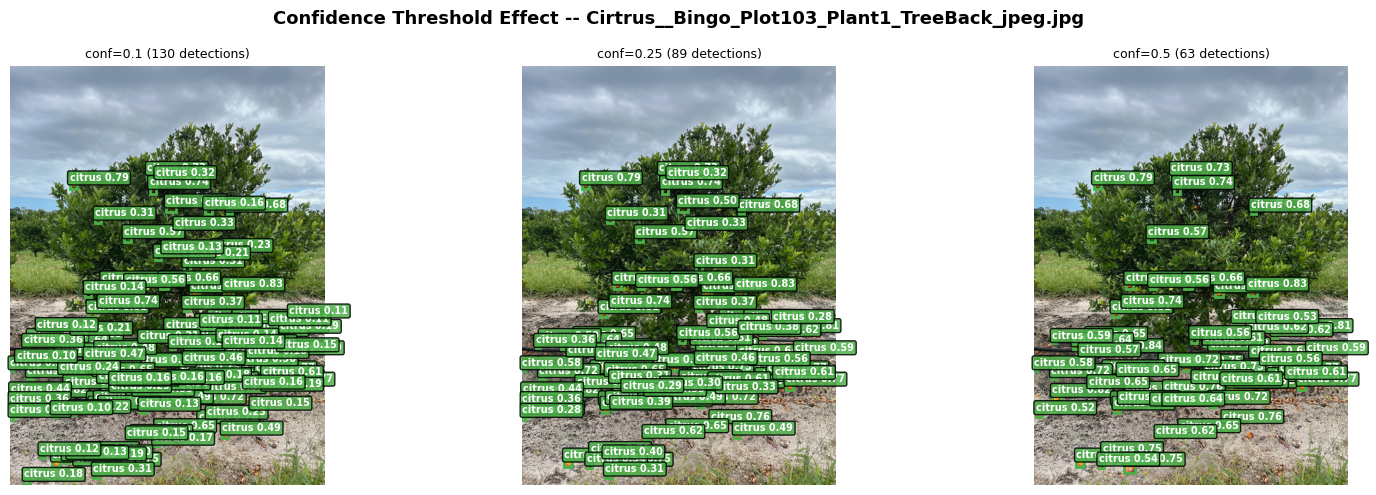

Low conf: more detections, more false positives.
High conf: fewer detections, higher precision, risk of missing real ingredients.


In [8]:
sample_img = test_image_paths[0]
thresholds = [0.1, 0.25, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Confidence Threshold Effect -- {sample_img.name}", fontsize=13, fontweight="bold")

for ax, conf_thresh in zip(axes, thresholds):
    img = Image.open(sample_img).convert("RGB")
    ax.imshow(img)
    res = best_model.predict(str(sample_img), conf=conf_thresh, iou=0.45, imgsz=640, verbose=False)[0]
    pred_boxes = []
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        pred_boxes.append((box.cls[0].item(), x1, y1, x2 - x1, y2 - y1, box.conf[0].item()))
    draw_boxes(ax, pred_boxes, unified_classes, class_colors, f"conf={conf_thresh} ({len(pred_boxes)} detections)")

plt.tight_layout()
plt.show()

print("Low conf: more detections, more false positives.")
print("High conf: fewer detections, higher precision, risk of missing real ingredients.")


In [10]:
from collections import Counter
import concurrent.futures as cf

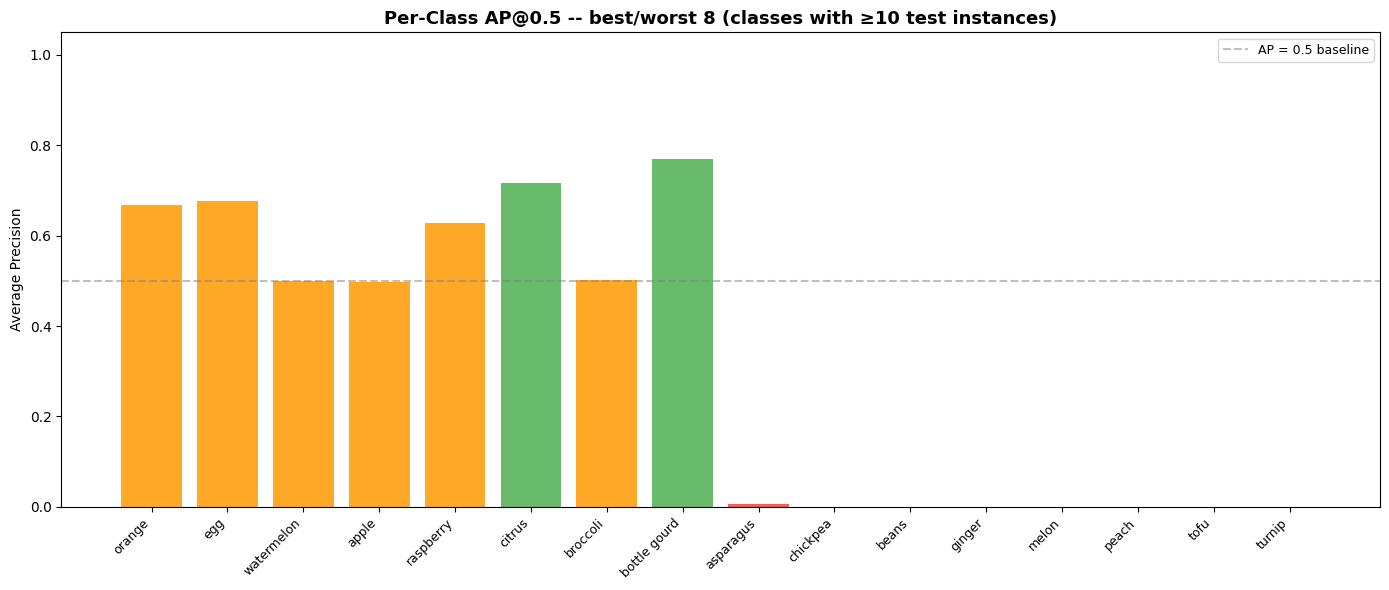

47 of 102 evaluated classes excluded (< 10 test instances)


In [12]:
# --- Trustworthy per-class AP chart: filters out classes with too few test instances to be
# meaningful (the 1.0/0.0 scores are mostly "1 test example, got it right/wrong", not real
# signal) rather than letting them dominate a naive top-N/bottom-N ranking.
MIN_TEST_INSTANCES = 10

def count_test_instances(img_path):
    label_path = img2label_path(img_path)
    counts = Counter()
    if not label_path.exists():
        return counts
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1
    return counts

test_instance_counts = Counter()
with cf.ThreadPoolExecutor(max_workers=32) as ex:
    for counts in ex.map(count_test_instances, test_image_paths):
        test_instance_counts.update(counts)

# Map class name -> test instance count (0 if class id not found)
name_to_id = {name: i for i, name in enumerate(unified_classes)}
per_class_ap["test_instances"] = per_class_ap["class"].map(
    lambda c: test_instance_counts.get(name_to_id.get(c, -1), 0)
)

# Cosmetic fix for display only -- doesn't touch underlying data/labels
per_class_ap["class"] = per_class_ap["class"].replace({"cornflakec": "cornflakes"})

reliable = per_class_ap[per_class_ap["test_instances"] >= MIN_TEST_INSTANCES]
excluded_count = len(per_class_ap) - len(reliable)

top_n = 8
plot_df = pd.concat([reliable.head(top_n), reliable.tail(top_n)])
bar_colors = ["#4CAF50" if ap >= 0.7 else "#FF9800" if ap >= 0.4 else "#F44336" for ap in plot_df["AP50"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df["class"], plot_df["AP50"], color=bar_colors, alpha=0.85)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="AP = 0.5 baseline")
ax.set_title(f"Per-Class AP@0.5 -- best/worst {top_n} (classes with \u226510 test instances)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Average Precision")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(RUNS_DIR / "per_class_ap_reliable.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"{excluded_count} of {len(per_class_ap)} evaluated classes excluded (< {MIN_TEST_INSTANCES} test instances)")

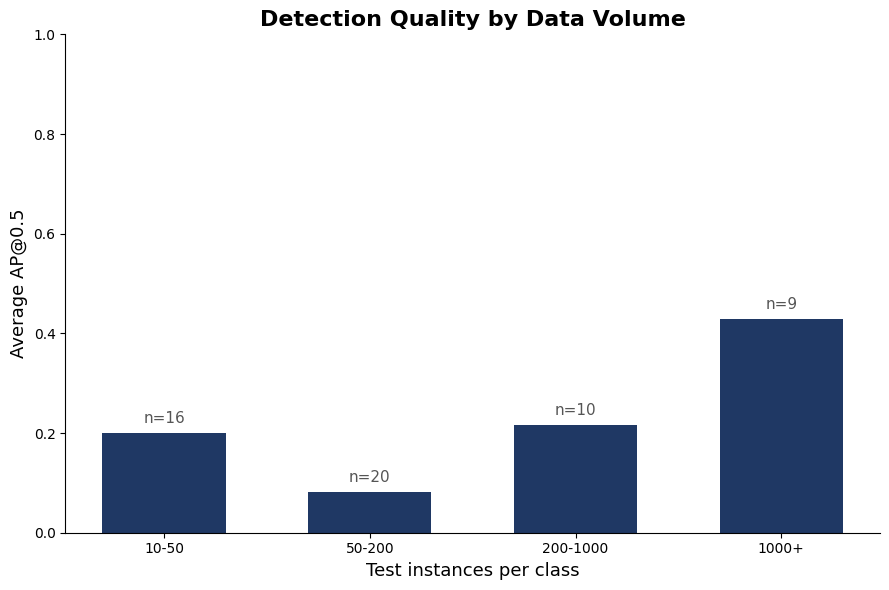

In [15]:
# Exclude <10 -- at 1-2 test instances, AP is essentially a coin flip (100% or 0%), which
# distorts a small-n average rather than reflecting real model quality.
bins = [10, 50, 200, 1000, float("inf")]
labels = ["10-50", "50-200", "200-1000", "1000+"]
per_class_ap["volume_tier"] = pd.cut(per_class_ap["test_instances"], bins=bins, labels=labels, right=False)

tier_stats = per_class_ap.groupby("volume_tier", observed=True).agg(
    mean_ap50=("AP50", "mean"),
    n_classes=("class", "count")
).reindex(labels)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(tier_stats.index.astype(str), tier_stats["mean_ap50"], color="#1F3864", width=0.6)

for bar, n in zip(bars, tier_stats["n_classes"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"n={n}", ha="center", fontsize=11, color="#555")

ax.set_xlabel("Test instances per class", fontsize=13)
ax.set_ylabel("Average AP@0.5", fontsize=13)
ax.set_title("Detection Quality by Data Volume", fontsize=16, fontweight="bold")  # neutral title -- let the bars speak
ax.set_ylim(0, 1.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(RUNS_DIR / "ap_by_volume_tier_v2.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Export for deployment (Phase 5 — Architecture / Serving)

In [11]:
export_path = best_model.export(format="onnx", imgsz=640, dynamic=True)
print(f"Exported to {export_path}")


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/Shareddrives/Computer Vision Final Project/Data/yolo_runs_colab_tar/baseline_yolov8s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 152, 8400) (21.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 392ms
Prepared 4 packages in 2.18s
Installed 4 packages in 399ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 3.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onn